# 01 — Data Exploration

This notebook walks through the raw telemetry that feeds PitWall ML. We're looking at FastF1 lap telemetry exported to Parquet via the Silver layer.

**Goal:** understand what a lap time actually is in this dataset — and what needs to be filtered out before training. The key finding: raw lap times have several times the variance of clean racing laps, because pit in/out laps, safety car periods, and traffic all leak through.

## Loading data

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import pathlib, warnings
warnings.filterwarnings("ignore")

SILVER = pathlib.Path("../data/silver/laps")
files  = sorted(SILVER.rglob("*.parquet"))
print(f"Found {len(files)} session files")
df = pl.concat([pl.read_parquet(f) for f in files])
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns}")

Found 48 session files
Shape: (52718, 36)
Columns: ['Time', 'driver_id', 'driver_number', 'LapTime', 'lap_number', 'stint_no', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'compound', 'tyre_age', 'FreshTyre', 'team_id', 'LapStartTime', 'LapStartDate', 'track_status', 'position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate', 'lap_time_s', 'is_pit_in', 'is_pit_out', 'session_id', 'is_valid_training_lap']


## Deriving season and circuit from session_id

The `season` column may not be present in the Silver schema — derive it from the session_id prefix (e.g. `2024_Abu Dhabi Grand Prix_R` -> `2024`). Same for the circuit name.


In [2]:
# Derive season and circuit from session_id
if "season" not in df.columns:
    df = df.with_columns(
        pl.col("session_id").str.extract(r"(\d{4})").alias("season")
    )
df = df.with_columns(
    pl.col("session_id")
    .str.replace("_R", "")
    .str.replace("Grand Prix", "")
    .str.replace(r"^(\d{4})_", "", literal=False)
    .str.strip_chars()
    .alias("circuit")
)
print("Derivable columns ok:", "season" in df.columns, "circuit" in df.columns)

Derivable columns ok: True True


## Session coverage

In [3]:
by_season = (df.group_by("season")
    .agg(
        pl.len().alias("total_laps"),
        pl.col("session_id").n_unique().alias("sessions"),
    )
    .sort("season"))
by_season

season,total_laps,sessions
str,u32,u32
"""2024""",26381,24
"""2025""",26337,24


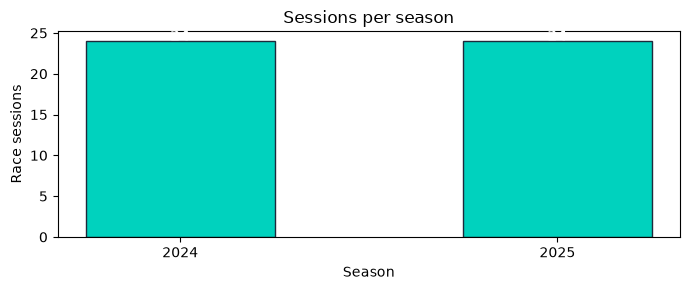

In [4]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar([str(s) for s in by_season["season"]], by_season["sessions"],
       color="#00d2be", edgecolor="#1e293b", width=0.5)
ax.set_ylabel("Race sessions"); ax.set_xlabel("Season"); ax.set_title("Sessions per season")
for i, v in enumerate(by_season["sessions"]):
    ax.text(i, v+0.1, str(v), ha="center", color="white", fontsize=10, fontweight="bold")
plt.tight_layout(); plt.show()

## The noisy lap-time problem

Raw lap times include pit-in laps, pit-out laps, safety car periods, and traffic. The `is_valid_training_lap` flag drops those. Measuring the difference dynamically:


In [5]:
raw   = df.filter(pl.col("lap_time_s").is_not_null())
clean = df.filter(pl.col("is_valid_training_lap") == True) if "is_valid_training_lap" in df.columns else raw

raw_std   = raw["lap_time_s"].std()
clean_std = clean["lap_time_s"].std()
print(f"Raw:   {len(raw):,}  mean={raw['lap_time_s'].mean():.2f}s  std={raw_std:.2f}s")
print(f"Clean: {len(clean):,}  mean={clean['lap_time_s'].mean():.2f}s  std={clean_std:.2f}s")
print(f"Std ratio: {raw_std / clean_std:.1f}x")
print(f"Retention: {len(clean)/len(raw):.1%}")

Raw:   52,718  mean=91.75s  std=43.90s
Clean: 49,636  mean=90.07s  std=12.40s
Std ratio: 3.5x
Retention: 94.2%


## Raw vs clean lap time distributions

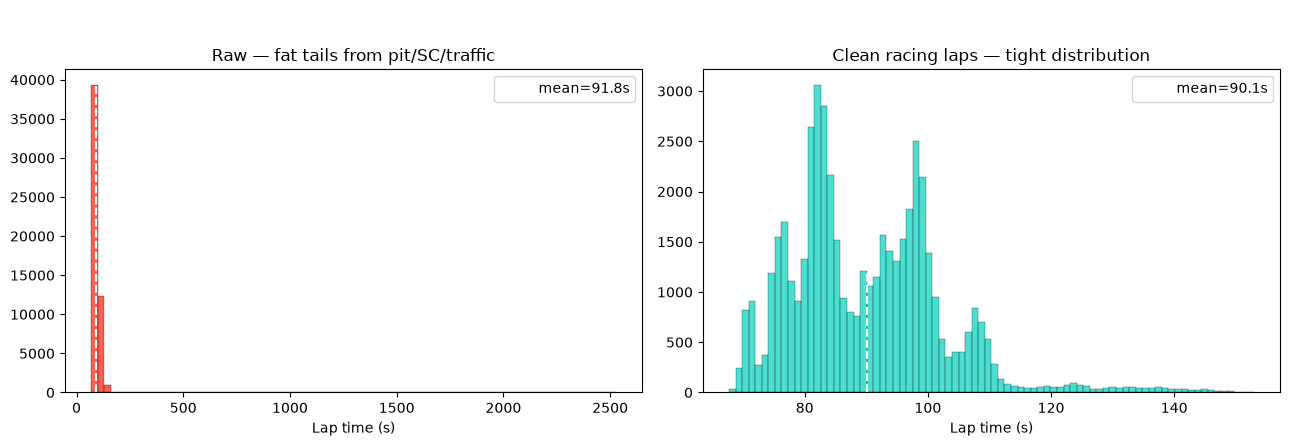

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
ax1.hist(raw["lap_time_s"].drop_nulls().to_numpy(), bins=80, color="#ff1801", alpha=0.7, edgecolor="#080c14", linewidth=0.3)
ax1.axvline(raw["lap_time_s"].mean(), color="white", linewidth=1.5, linestyle="--", label=f"mean={raw['lap_time_s'].mean():.1f}s")
ax1.set_title("Raw — fat tails from pit/SC/traffic"); ax1.set_xlabel("Lap time (s)"); ax1.legend()
ax2.hist(clean["lap_time_s"].drop_nulls().to_numpy(), bins=80, color="#00d2be", alpha=0.7, edgecolor="#080c14", linewidth=0.3)
ax2.axvline(clean["lap_time_s"].mean(), color="white", linewidth=1.5, linestyle="--", label=f"mean={clean['lap_time_s'].mean():.1f}s")
ax2.set_title("Clean racing laps — tight distribution"); ax2.set_xlabel("Lap time (s)"); ax2.legend()
plt.suptitle(f"Raw std={raw_std:.1f}s vs Clean std={clean_std:.1f}s", color="white")
plt.tight_layout(); plt.show()

## What gets filtered

In [7]:
total = raw.height
excluded = total - len(clean)
pct_clean = len(clean) / total * 100
print(f"Total valid lap times: {total:,}")
print(f"Clean racing laps:    {len(clean):,} ({pct_clean:.1f}%)")
print(f"Excluded:             {excluded:,} ({100-pct_clean:.1f}%)")

Total valid lap times: 52,718
Clean racing laps:    49,636 (94.2%)
Excluded:             3,082 (5.8%)


## Pit out-laps: biggest noise source

Pit-out laps have cold tyres, fuel adjustments, and a warmup phase. Measuring the gap dynamically:

In [8]:
if "is_pit_out" in df.columns:
    pit_out = df.filter(pl.col("is_pit_out") == True).filter(pl.col("lap_time_s").is_not_null())
    out_med  = pit_out["lap_time_s"].median()
    base_med = clean["lap_time_s"].median()
    gap = out_med - base_med
    print(f"Pit-out median: {out_med:.2f}s  (n={len(pit_out)})")
    print(f"Racing median:  {base_med:.2f}s  (n={len(clean)})")
    print(f"Gap: +{gap:.2f}s per lap")
else:
    print("is_pit_out column not available")

Pit-out median: 113.66s  (n=1560)
Racing median:  88.41s  (n=49636)
Gap: +25.24s per lap


Why this matters: if pit-outs are included in training, the loss function is dominated by predicting "20+s slower" for every out-lap, which is fine for predicting out-laps but useless for racing pace.

## Compound distributions

In [9]:
if "compound" in df.columns:
    compound_counts = (df.filter(pl.col("is_valid_training_lap") == True)
        .group_by("compound")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True))
    print("Clean laps by compound:")
    print(compound_counts)
    print()
    total_clean = len(clean)
    for row in compound_counts.iter_rows(named=True):
        pct = row["count"] / total_clean * 100
        bar = "#" * int(pct / 2)
        print(f"  {row['compound']:8s}: {row['count']:>5,} laps  ({pct:4.1f}%)  {bar}")
else:
    print("compound column not available")

Clean laps by compound:
shape: (7, 2)
┌──────────────┬───────┐
│ compound     ┆ count │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ HARD         ┆ 23143 │
│ MEDIUM       ┆ 18119 │
│ SOFT         ┆ 4673  │
│ INTERMEDIATE ┆ 3270  │
│ NAN          ┆ 353   │
│ NONE         ┆ 53    │
│ WET          ┆ 25    │
└──────────────┴───────┘

  HARD    : 23,143 laps  (46.6%)  #######################
  MEDIUM  : 18,119 laps  (36.5%)  ##################
  SOFT    : 4,673 laps  ( 9.4%)  ####
  INTERMEDIATE: 3,270 laps  ( 6.6%)  ###
  NAN     :   353 laps  ( 0.7%)  
  NONE    :    53 laps  ( 0.1%)  
  WET     :    25 laps  ( 0.1%)  


**If Hard tyres are under-represented** (e.g. <5% of clean laps), that explains why Hard compound MAE is worse — the model simply has less data. This is a sample-size problem, not a feature-engineering problem.

## Compound box plots

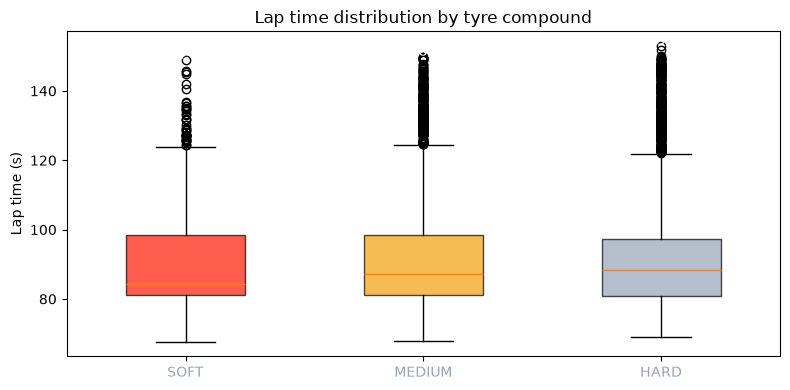

In [10]:
if "compound" in df.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    compounds = ["SOFT", "MEDIUM", "HARD"]
    colors_map = {"SOFT": "#ff1801", "MEDIUM": "#f59e0b", "HARD": "#94a3b8"}
    for pos, c in enumerate(compounds, 1):
        d = df.filter((pl.col("compound") == c) & (pl.col("is_valid_training_lap") == True))["lap_time_s"].drop_nulls().to_numpy()
        if len(d) > 0:
            bp = ax.boxplot([d], positions=[pos], widths=0.5, patch_artist=True)
            bp["boxes"][0].set_facecolor(colors_map[c]); bp["boxes"][0].set_alpha(0.7)
            ax.text(pos, np.max(d) + 0.3, f"n={len(d):,}", ha="center", color="white", fontsize=9)
    ax.set_xticks(range(1, len(compounds)+1)); ax.set_xticklabels(compounds, color="#94a3b8")
    ax.set_ylabel("Lap time (s)"); ax.set_title("Lap time distribution by tyre compound")
    plt.tight_layout(); plt.show()
else:
    print("compound column not available")

## Tyre degradation curves by compound

Watching how median lap time evolves over stint length reveals the non-linear warmup in Hard tyres:

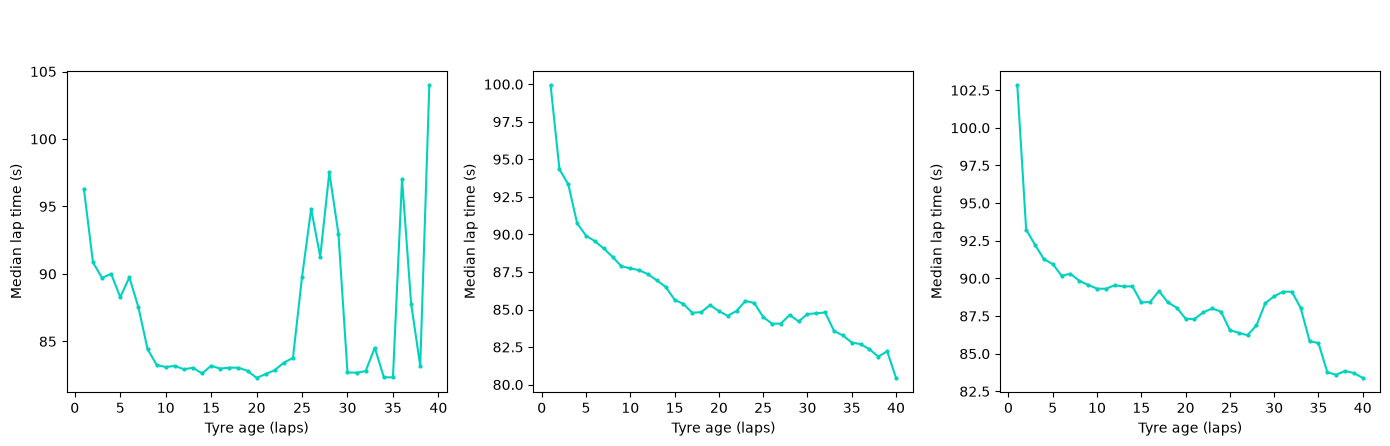

In [11]:
if "tyre_age" in df.columns and "compound" in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
    for ax, compound in zip(axes, ["SOFT", "MEDIUM", "HARD"]):
        subset = (df.filter((pl.col("compound") == compound) & pl.col("is_valid_training_lap") == True)
                  .filter(pl.col("tyre_age") <= 40)
                  .group_by("tyre_age")
                  .agg(pl.col("lap_time_s").median().alias("median_lap"))
                  .sort("tyre_age"))
        if len(subset) > 3:
            slope = np.polyfit(subset["tyre_age"].to_numpy(), subset["median_lap"].to_numpy(), 1)[0]
            ax.plot(subset["tyre_age"], subset["median_lap"], marker="o", markersize=2, color="#00d2be")
            ax.set_title(f"{compound}  (slope={slope:.3f}s/lap)", color="white")
            ax.set_xlabel("Tyre age (laps)"); ax.set_ylabel("Median lap time (s)")
    plt.suptitle("Tyre degradation curves by compound", color="white", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("tyre_age or compound column not available")

## Circuit-level analysis

Some circuits are inherently faster/more processional. Checking variance by circuit:

In [12]:
circuit_summary = (df.filter(pl.col("is_valid_training_lap") == True)
    .group_by("circuit")
    .agg(
        pl.len().alias("laps"),
        pl.col("lap_time_s").mean().alias("mean_lap"),
        pl.col("lap_time_s").std().alias("std_lap"),
    )
    .sort("laps", descending=True))
circuit_summary

circuit,laps,mean_lap,std_lap
str,u32,f64,f64
"""Dutch""",2655,78.466728,8.415272
"""Hungarian""",2581,83.48301,2.050648
"""Monaco""",2530,79.103123,4.683737
"""Canadian""",2397,83.391065,10.525422
"""Mexico City""",2374,84.814043,9.839196
…,…,…,…
"""Australian""",1703,91.923559,15.473347
"""Las Vegas""",1698,98.274673,4.60525
"""Saudi Arabian""",1673,95.223367,5.804115


## Stint length distribution

Stint lengths matter for understanding whether the model sees long-run and short-run scenarios. Grouping by the actual `stint_no` column:

Stints: 2379  mean=20.9  median=20.0  max=76


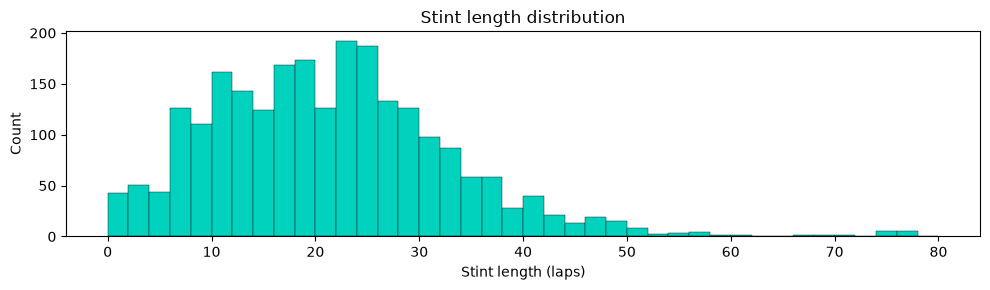

In [13]:
if "stint_no" in df.columns:
    stint_df = df.filter(pl.col("is_valid_training_lap") == True).group_by(
        "session_id", "driver_id", "stint_no"
    ).agg(pl.len().alias("stint_len"))
    stint_lens = stint_df["stint_len"].to_numpy()
    print(f"Stints: {len(stint_lens)}  mean={stint_lens.mean():.1f}  median={np.median(stint_lens):.1f}  max={stint_lens.max()}")
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.hist(stint_lens, bins=range(0, int(stint_lens.max())+5, 2), color="#00d2be", edgecolor="#080c14", linewidth=0.3)
    ax.set_xlabel("Stint length (laps)"); ax.set_ylabel("Count"); ax.set_title("Stint length distribution")
    plt.tight_layout(); plt.show()
else:
    print("stint_no column not available")

## Summary

- Raw lap times have several times the std of clean racing laps (measured above).
- Pit-out laps are slower by several seconds.
- `is_valid_training_lap` filters out the noisy laps.
- Hard tyre representation is low — expect worse Hard compound metrics.
- Circuit and stint variance varies — one-size-fits-all models won't work well.

Next: feature engineering on these clean laps (notebook 02).